In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("Cleaned_Surat_Business_dataset.csv")

In [3]:
df.head()

,Sr.No,Area,Address/Street,Shop Name,Category,Rating,No. of Reviews,Website(Yes/No),Website Needed?(Yes/No),Opportunity Flag(High Rating + No Website)
0,1,Adajan,Pal Gam,Regnant Clothing,Clothing,4.9,243,No,Yes,Yes
1,2,Adajan,Pal Gam,Madhuram Dairy & Sweet,Dairy,4.2,13,No,No,Yes
2,3,Adajan,Pal Gam,Wallet Hypermart,Supermarket,4.2,220,No,Yes,Yes
3,4,Adajan,Pal Gam,Shri Umiya General Store,Grocery,4.8,17,No,No,Yes
4,5,Adajan,Pal Gam,Yuttam Hardware & Building Materials,hardware store,4.5,19,No,No,Yes


In [4]:
df.shape

(691, 10)

In [5]:
df.columns

Index(['Sr.No', 'Area', 'Address/Street', 'Shop Name', 'Category', 'Rating',
       'No. of Reviews', 'Website(Yes/No)', 'Website Needed?(Yes/No)',
       'Opportunity Flag(High Rating + No Website)'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 691 entries, 0 to 690
Data columns (total 10 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Sr.No                                       691 non-null    int64  
 1   Area                                        691 non-null    str    
 2   Address/Street                              691 non-null    str    
 3   Shop Name                                   691 non-null    str    
 4   Category                                    691 non-null    str    
 5   Rating                                      691 non-null    float64
 6   No. of Reviews                              691 non-null    int64  
 7   Website(Yes/No)                             690 non-null    str    
 8   Website Needed?(Yes/No)                     691 non-null    str    
 9   Opportunity Flag(High Rating + No Website)  691 non-null    str    
dtypes: float64(1), int64(2), 

In [7]:
df.isnull().sum()

Sr.No                                         0
Area                                          0
Address/Street                                0
Shop Name                                     0
Category                                      0
Rating                                        0
No. of Reviews                                0
Website(Yes/No)                               1
Website Needed?(Yes/No)                       0
Opportunity Flag(High Rating + No Website)    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns = df.columns.str.strip()

In [10]:
text_columns = df.select_dtypes(include=['object','string']).columns

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

In [11]:
df['Category'].nunique()

136

In [12]:
df['Category'].value_counts()

Category
Clothing                       50
Medical store                  47
Electronics Store              38
Medical Clinic                 37
Grocery                        36
                               ..
Electronics manufacturer        1
Computer repair service         1
computer service                1
Physiotherapy                   1
Jewllery Equipment Supplier     1
Name: count, Length: 136, dtype: int64

In [13]:
df['Category'] = df['Category'].str.strip().str.title()

In [14]:
df['Category'] = df['Category'].replace({
    'Cafã©': 'Cafe',
    'Cafã©/Coffee Shop': 'Cafe/Coffee Shop'
})

In [15]:
df[df['Category'].str.contains('Caf', na=False)]

,Sr.No,Area,Address/Street,Shop Name,Category,Rating,No. of Reviews,Website(Yes/No),Website Needed?(Yes/No),Opportunity Flag(High Rating + No Website)
16,17,Adajan,Pal Gam,GAG Coffee,Café,4.8,107,yes,No,No
19,20,Adajan,Pal Gam,Indian Idli- Authentic South Indian Cafe,Restaurant/Cafe,5.0,84,No,No,Yes
45,46,Adajan,Pal Gam,Larista-The Coffee House,Café/Coffee Shop,4.7,130,No,Yes,Yes
50,51,Adajan,Pal Gam,Kafe Insperiaa,Café,4.8,675,Yes,No,No
183,184,Adajan,L.P Savani Road,Ajay's Café,Café,4.3,2934,Yes,No,No
184,185,Adajan,L.P Savani Road,Cheese corner,Café,4.7,30,No,No,Yes
185,186,Adajan,L.P Savani Road,My Cold Zone,Café,4.4,378,No,No,Yes
275,276,Adajan,Gujarat Gas Circle,Indian idli cafe,Café,4.8,97,No,No,Yes
351,352,Adajan,Adajan Gam,Rennoki,Café,4.8,482,Yes,No,No
365,366,Adajan,Mora Bhagal,Waffle World,Café,4.5,152,Yes,No,No


In [16]:
df['Category'] = df['Category'].replace({
    'Electronic Store': 'Electronics Store',
    'Electronics': 'Electronics Store',

    'Medical Store': 'Medical Store',
    'Medical Laboratory': 'Medical Laboratory',
    'Medical Laboratory': 'Medical Laboratory',

    'Salon': 'Hair Salon',
    'Beauty Salon': 'Beauty Parlour',
    'Beautician': 'Beauty Parlour',

    'Bakery Shop': 'Bakery',
    'Bakery And Cake Shop': 'Cake Shop',
    'Bakery & Cake Shop': 'Cake Shop',

    'Repairing Shop': 'Repair Shop',
    'Electronic Repair Shop': 'Repair Shop',
    'Electronics Repair Store': 'Repair Shop',
    'Electric Repair': 'Repair Shop',

    'Computer Repair Service': 'Computer Support & Services',
    'Computer Service': 'Computer Support & Services',

    'Gas Shop': 'Gas Agency',
    'Gas Supplier': 'Gas Agency',

    'Super Store': 'Supermarket'
})

In [17]:
df['Category'].nunique()

114

In [18]:
df['Category'] = df['Category'].replace({
    'Physiotheraphy': 'Physiotherapy',
    'Pharmacy': 'Medical Store',
    'Stationary': 'Stationary Store',
    'Gift Store': 'Gift Shop',
    'Dairy Store': 'Dairy',
    'Ice Cream Store': 'Ice Cream',
    'Restaurant/Cafe': 'Restaurant',
    'Café/Coffee Shop': 'Coffee Shop',
    'Fast Food Restaurant': 'Fast Food',
    'Pizza Restaurant': 'Restaurant',
    'Tea Shop': 'Tea Store'
})

In [19]:
df['Category'].nunique()

103

In [20]:
sorted(df['Category'].unique())

['Appliance Store',
 'Aquarium',
 'Auto Parts Store',
 'Ayurvedic Clinic',
 'Ayurvedic Store',
 'Baby Store',
 'Bag Store',
 'Bakery',
 'Bakery Equipment',
 'Bathroom Supply Store',
 'Battery Store',
 'Beauty Parlour',
 'Beauty Supple Store',
 'Bicycle Store',
 'Book Store',
 'Boutique & Tailor',
 'Café',
 'Cake Shop',
 'Clothing',
 'Clothing  Accessories Store',
 'Coffee Shop',
 'Computer Store',
 'Computer Support & Services',
 'Cosmetics Store',
 'Craft Store',
 'Curtain & Bedsheet Store',
 'Dairy',
 'Diagnostic Center',
 'Electrical Store',
 'Electrical Supply Store',
 'Electricals & Tool Supplier',
 'Electriccal Supply Store',
 'Electronic Accessories',
 'Electronics Manufacturer',
 'Electronics Store',
 'Fast Food',
 'Fitness Center',
 'Food Market',
 'Food Products Supplier',
 'Fruit Store',
 'Furniture Store',
 'Gas Agency',
 'Gas Station',
 'General Store',
 'Gift Shop',
 'Gifts & Cosmetics Store',
 'Grocery',
 'Gym',
 'Hair Salon',
 'Hair Transplantation Clinic',
 'Hardware S

In [21]:
df['Category'] = df['Category'].str.replace(r'\s+', ' ', regex=True)

In [22]:
df['Category'] = df['Category'].replace({
    'Electriccal Supply Store': 'Electrical Supply Store'
})

In [23]:
df['Rating'].dtype
df['Rating'].isnull().sum()

np.int64(0)

In [24]:
df['Rating'].describe()

count    691.000000
mean       4.352677
std        1.056479
min        0.000000
25%        4.200000
50%        4.700000
75%        4.900000
max        5.000000
Name: Rating, dtype: float64

In [25]:
df[(df['Rating'] < 0) | (df['Rating'] > 5)]

,Sr.No,Area,Address/Street,Shop Name,Category,Rating,No. of Reviews,Website(Yes/No),Website Needed?(Yes/No),Opportunity Flag(High Rating + No Website)


In [26]:
df['Rating'] = df['Rating'].fillna(df['Rating'].median())

In [27]:
df['No. of Reviews'] = pd.to_numeric(
    df['No. of Reviews'],
    errors='coerce'
)

In [28]:
df['No. of Reviews'].isnull().sum()

np.int64(0)

In [29]:
df['No. of Reviews'] = df['No. of Reviews'].fillna(0)

In [30]:
df[df['No. of Reviews'] < 0]

,Sr.No,Area,Address/Street,Shop Name,Category,Rating,No. of Reviews,Website(Yes/No),Website Needed?(Yes/No),Opportunity Flag(High Rating + No Website)


In [31]:
df['Website(Yes/No)'].value_counts(dropna=False)

Website(Yes/No)
No     532
Yes    135
yes     21
no       2
NaN      1
Name: count, dtype: int64

In [32]:
df['Website(Yes/No)'] = (
    df['Website(Yes/No)']
    .astype(str)
    .str.strip()
    .str.title()
)

In [50]:
df[df['Website Needed?(Yes/No)'].isin(['no', 'M'])]

,Sr.No,Area,Address/Street,Shop Name,Category,Rating,No. of Reviews,Website(Yes/No),Website Needed?(Yes/No),Opportunity Flag(High Rating + No Website)
24,25,Adajan,Pal Gam,Padubha Golavala,Ice Gola Shop,5.0,86,No,no,Yes
125,126,Adajan,Honey Park Rd,Amazing Gift & Toys,Gift Shop,5.0,45,No,no,Yes
554,555,Adajan,Palanpur Canal Road,Yellow Bite,Fast Food,5.0,20,No,M,Yes


In [51]:
df['Website Needed?(Yes/No)'] = (
    df['Website Needed?(Yes/No)']
    .astype(str)
    .str.strip()
)

df['Website Needed?(Yes/No)'] = df[
    'Website Needed?(Yes/No)'
].replace({
    'no': 'No',
    'M': 'No'      # change to 'Yes' if that row should actually be Yes
})

In [52]:
df['Website Needed?(Yes/No)'].value_counts(dropna=False)

Website Needed?(Yes/No)
No     645
Yes     46
Name: count, dtype: int64

In [33]:
df['Website(Yes/No)'].value_counts(dropna=False)

Website(Yes/No)
No     534
Yes    156
NaN      1
Name: count, dtype: int64

In [34]:
df['Website(Yes/No)'] = df['Website(Yes/No)'].replace('Nan', 'No')

In [35]:
df['Website(Yes/No)'].value_counts(dropna=False)

Website(Yes/No)
No     534
Yes    156
NaN      1
Name: count, dtype: int64

In [36]:
df[df['Website(Yes/No)'].isna()]

,Sr.No,Area,Address/Street,Shop Name,Category,Rating,No. of Reviews,Website(Yes/No),Website Needed?(Yes/No),Opportunity Flag(High Rating + No Website)
140,141,Adajan,Honey Park Rd,Paradise Dental Care,Medical Clinic,5.0,71,NaN,No,Yes


In [38]:
df['Website(Yes/No)'] = df['Website(Yes/No)'].fillna('No')

In [39]:
df['Website(Yes/No)'].value_counts(dropna=False)

Website(Yes/No)
No     535
Yes    156
Name: count, dtype: int64

In [40]:
df[['Website(Yes/No)', 'Website Needed?(Yes/No)']].head(20)

,Website(Yes/No),Website Needed?(Yes/No)
0,No,Yes
1,No,No
2,No,Yes
3,No,No
4,No,No
5,No,No
6,Yes,No
7,Yes,No
8,No,No
9,No,Yes


In [11]:
df['Opportunity Flag(High Rating + No Website)'].value_counts(dropna=False)

Opportunity Flag(High Rating + No Website)
Yes    448
No     243
Name: count, dtype: int64

In [12]:
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100


website_col = 'Website(Yes/No)'
needed_col = 'Website Needed?(Yes/No)'
opp_col = 'Opportunity Flag(High Rating + No Website)'
area_col = 'Address/Street'  

total_businesses = len(df)
total_categories = df['Category'].nunique()
total_areas = df[area_col].nunique()
avg_rating = round(df['Rating'].mean(), 2)
with_website = (df[website_col] == 'Yes').sum()
without_website = (df[website_col] == 'No').sum()
needs_website = (df[needed_col] == 'Yes').sum()
opportunity_count = (df[opp_col] == 'Yes').sum()

kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Businesses', 'Total Categories', 'Total Areas/Sub-Areas',
        'Average Rating', 'Businesses with Website', 'Businesses without Website',
        'Businesses Needing Website', 'Opportunity Businesses (High Rating + No Website)'
    ],
    'Value': [
        total_businesses, total_categories, total_areas,
        avg_rating, with_website, without_website,
        needs_website, opportunity_count
    ]
})
kpi_summary

,KPI,Value
0,Total Businesses,691.00
1,Total Categories,102.00
2,Total Areas/Sub-Areas,10.00
3,Average Rating,4.35
4,Businesses with Website,156.00
5,Businesses without Website,535.00
6,Businesses Needing Website,46.00
7,Opportunity Businesses (High Rating + No Website),448.00


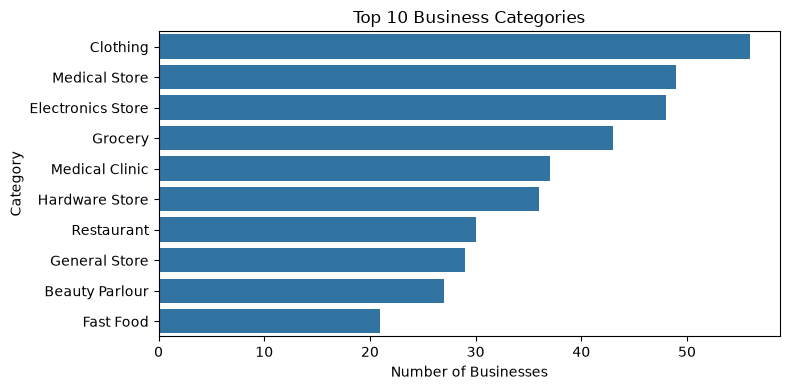

Category
Clothing             56
Medical Store        49
Electronics Store    48
Grocery              43
Medical Clinic       37
Hardware Store       36
Restaurant           30
General Store        29
Beauty Parlour       27
Fast Food            21
Name: count, dtype: int64

In [8]:
#Top 10 Busniess Category
top_categories = df['Category'].value_counts().head(10)

plt.figure(figsize=(8,4))
sns.barplot(x=top_categories.values, y=top_categories.index, )
plt.title('Top 10 Business Categories')
plt.xlabel('Number of Businesses')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('top10_categories.png')
plt.show()

top_categories

C:\Users\devya\AppData\Local\Temp\ipykernel_2896\117925230.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=area_counts.values, y=area_counts.index,  palette='flare')


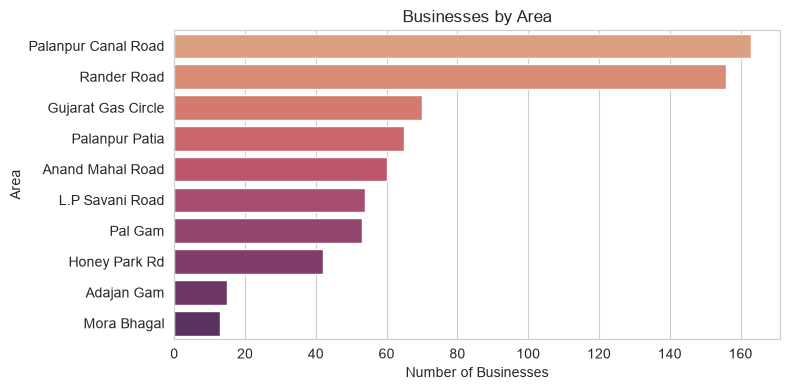

Address/Street
Palanpur Canal Road    163
Rander Road            156
Gujarat Gas Circle      70
Palanpur Patia          65
Anand Mahal Road        60
L.P Savani Road         54
Pal Gam                 53
Honey Park Rd           42
Adajan Gam              15
Mora Bhagal             13
Name: count, dtype: int64

In [14]:
#Businesses By Area(Sub-Area)
area_counts = df[area_col].value_counts().head(15)

plt.figure(figsize=(8,4))
sns.barplot(x=area_counts.values, y=area_counts.index,  palette='flare')
plt.title('Businesses by Area')
plt.xlabel('Number of Businesses')
plt.ylabel('Area')
plt.tight_layout()
plt.savefig('businesses_by_area.png')
plt.show()

area_counts

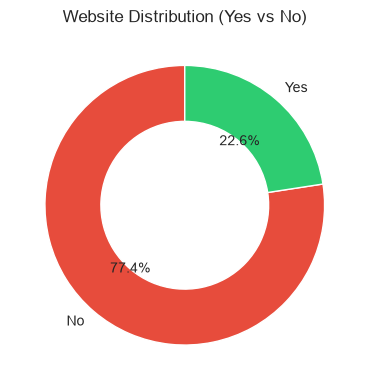

Website(Yes/No)
No     535
Yes    156
Name: count, dtype: int64

In [63]:
#Website Distribution
website_counts = df[website_col].value_counts()

plt.figure(figsize=(4,4))
colors = ['#e74c3c', '#2ecc71']
plt.pie(website_counts.values, labels=website_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors, wedgeprops={'width':0.4})
plt.title('Website Distribution (Yes vs No)')
plt.tight_layout()
plt.savefig('website_distribution.png')
plt.show()

website_counts

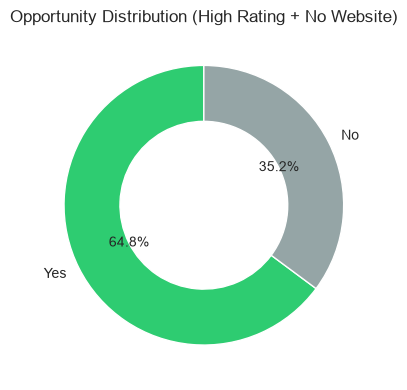

Opportunity Flag(High Rating + No Website)
Yes    448
No     243
Name: count, dtype: int64

In [78]:
#Opportunity Distribution
opp_counts = df[opp_col].value_counts()

plt.figure(figsize=(8,4))
colors = ['#2ecc71', '#95a5a6']
plt.pie(opp_counts.values, labels=opp_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors, wedgeprops={'width':0.4})
plt.title('Opportunity Distribution (High Rating + No Website)')
plt.tight_layout()
plt.savefig('opportunity_distribution.png')
plt.show()

opp_counts

C:\Users\devya\AppData\Local\Temp\ipykernel_2896\316185139.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating_by_cat.values, y=avg_rating_by_cat.index, palette='flare')


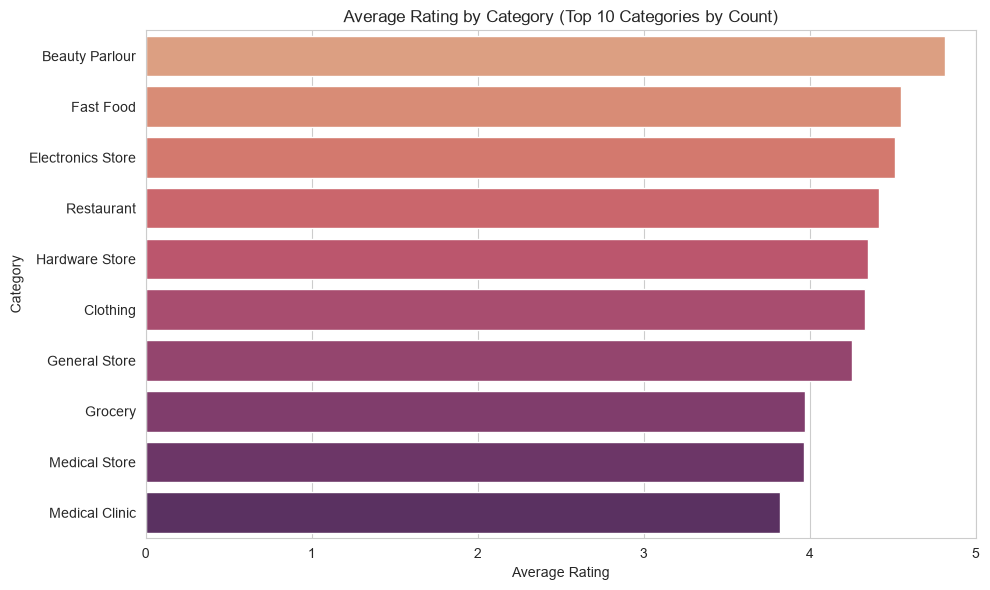

Category
Beauty Parlour       4.811111
Fast Food            4.547619
Electronics Store    4.510417
Restaurant           4.413333
Hardware Store       4.350000
Clothing             4.328571
General Store        4.251724
Grocery              3.967442
Medical Store        3.961224
Medical Clinic       3.818919
Name: Rating, dtype: float64

In [15]:
#Average Rating By Category
top10_cats = df['Category'].value_counts().head(10).index
avg_rating_by_cat = df[df['Category'].isin(top10_cats)].groupby('Category')['Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=avg_rating_by_cat.values, y=avg_rating_by_cat.index, palette='flare')
plt.title('Average Rating by Category (Top 10 Categories by Count)')
plt.xlabel('Average Rating')
plt.ylabel('Category')
plt.xlim(0,5)
plt.tight_layout()
plt.savefig('avg_rating_by_category.png')
plt.show()

avg_rating_by_cat

C:\Users\devya\AppData\Local\Temp\ipykernel_2896\3466650978.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=opp_by_category.values, y=opp_by_category.index, palette='flare')


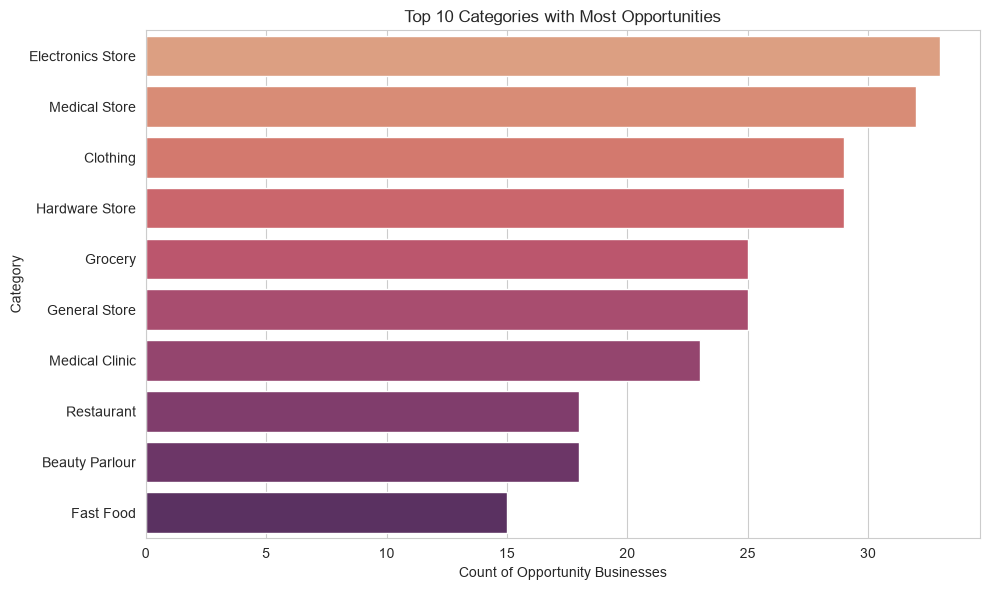

Category
Electronics Store    33
Medical Store        32
Clothing             29
Hardware Store       29
Grocery              25
General Store        25
Medical Clinic       23
Restaurant           18
Beauty Parlour       18
Fast Food            15
Name: count, dtype: int64

In [13]:
#Categories with Most Opportunities
opp_by_category = df[df[opp_col] == 'Yes']['Category'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=opp_by_category.values, y=opp_by_category.index, palette='flare')
plt.title('Top 10 Categories with Most Opportunities')
plt.xlabel('Count of Opportunity Businesses')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('opportunities_by_category.png')
plt.show()

opp_by_category

In [80]:
#Top Opportunity Businesses(Rating & Reviews)
top_opportunity_businesses = (
    df[df[opp_col] == 'Yes']
    [['Shop Name', area_col, 'Category', 'Rating', 'No. of Reviews', website_col]]
    .sort_values(['Rating', 'No. of Reviews'], ascending=[False, False])
    .head(10)
    .reset_index(drop=True)
)
top_opportunity_businesses

,Shop Name,Address/Street,Category,Rating,No. of Reviews,Website(Yes/No)
0,Twakkal Mobile Point,Rander Road,Mobile Accessories,5.0,206,No
1,Bs Fast Food,Rander Road,Fast Food,5.0,180,No
2,Sv Unisex Salon,L.P Savani Road,Hair Salon,5.0,92,No
3,Padubha Golavala,Pal Gam,Ice Gola Shop,5.0,86,No
4,Prime Medical,Anand Mahal Road,Medical Store,5.0,86,No
5,Indian Idli- Authentic South Indian Cafe,Pal Gam,Restaurant,5.0,84,No
6,My Eyes Optics,Honey Park Rd,Optical Store,5.0,83,No
7,Paradise Dental Care,Honey Park Rd,Medical Clinic,5.0,71,No
8,Ply Plus,Adajan Gam,Hardware Store,5.0,71,No
9,Gurukrupa Medical And General Store,Pal Gam,Medical Store,5.0,67,No


C:\Users\devya\AppData\Local\Temp\ipykernel_26944\1566233686.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=opp_by_area.values, y=opp_by_area.index, palette='rocket')


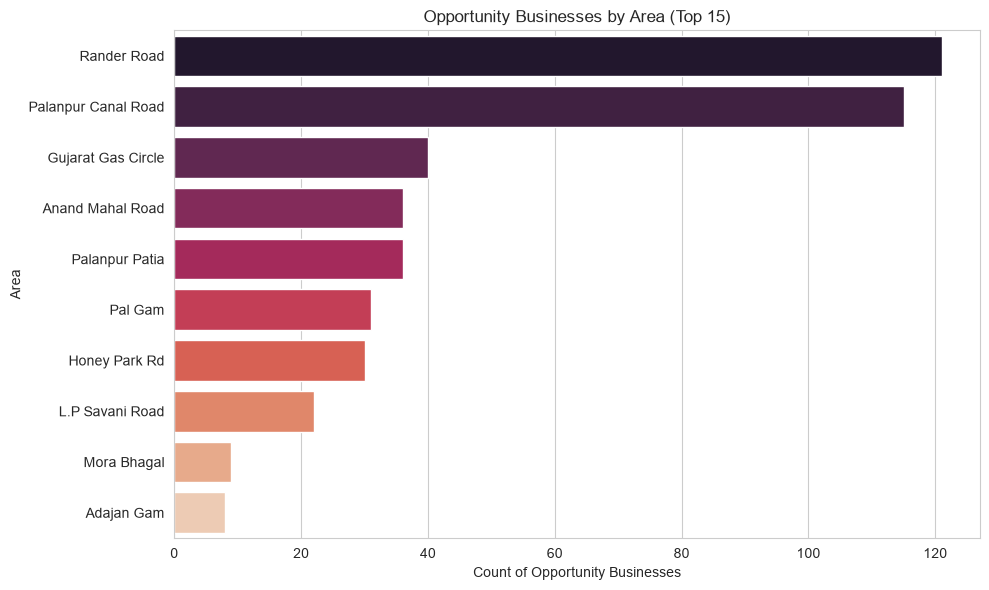

Address/Street
Rander Road            121
Palanpur Canal Road    115
Gujarat Gas Circle      40
Anand Mahal Road        36
Palanpur Patia          36
Pal Gam                 31
Honey Park Rd           30
L.P Savani Road         22
Mora Bhagal              9
Adajan Gam               8
Name: count, dtype: int64

In [81]:
#Opportunity Businesses By Area
opp_by_area = df[df[opp_col] == 'Yes'][area_col].value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=opp_by_area.values, y=opp_by_area.index, palette='rocket')
plt.title('Opportunity Businesses by Area')
plt.xlabel('Count of Opportunity Businesses')
plt.ylabel('Area')
plt.tight_layout()
plt.savefig('opportunities_by_area.png')
plt.show()

opp_by_area

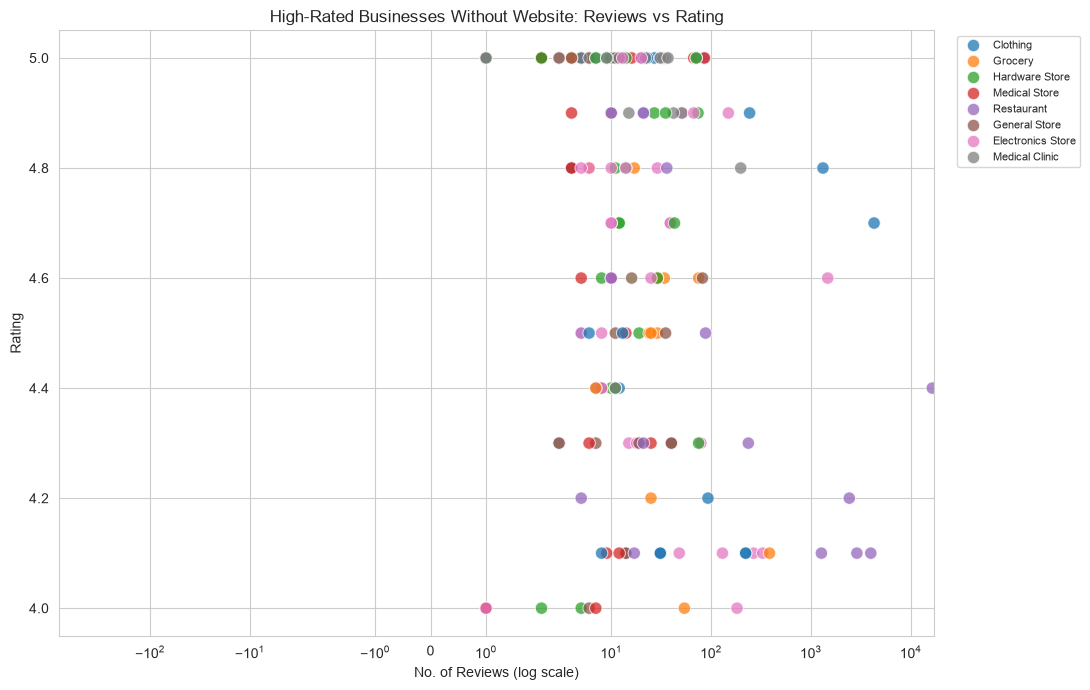

In [82]:
#High-Rated Businesses Without Website(Reviews vs Rating)
opp_df = df[df[opp_col] == 'Yes'].copy()
top_cats_for_scatter = opp_df['Category'].value_counts().head(8).index
opp_df_plot = opp_df[opp_df['Category'].isin(top_cats_for_scatter)]

plt.figure(figsize=(11,7))
sns.scatterplot(
    data=opp_df_plot, x='No. of Reviews', y='Rating',
    hue='Category', s=80, alpha=0.75
)
plt.xscale('symlog')
plt.title('High-Rated Businesses Without Website: Reviews vs Rating')
plt.xlabel('No. of Reviews (log scale)')
plt.ylabel('Rating')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('reviews_vs_rating_scatter.png')
plt.show()

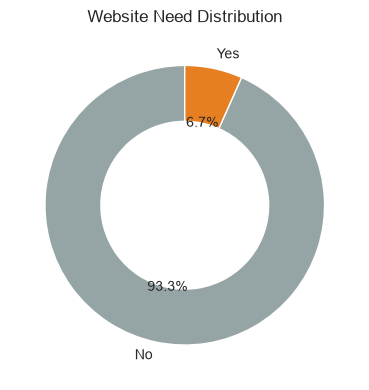

Website Needed?(Yes/No)
No     645
Yes     46
Name: count, dtype: int64

In [90]:
#Website  Distribution
needed_counts = df[needed_col].value_counts()

plt.figure(figsize=(8,4))
colors = ['#95a5a6', '#e67e22']
plt.pie(needed_counts.values, labels=needed_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors, wedgeprops={'width':0.4})
plt.title('Website Need Distribution')
plt.tight_layout()
plt.savefig('website_Need_distribution.png')
plt.show()

needed_counts

In [53]:
df.to_csv(
    'Cleaned_Surat_Business_Dataset.csv',
    index=False
)

In [47]:
import os
os.getcwd()

'C:\\Users\\devya\\Documents'